In [ ]:
import requests
import json
from pathlib import Path
import pandas as pd
from itertools import combinations
import networkx as nx
!pip install GitPython unidecode

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 3.9 MB/s eta 0:00:00


In [ ]:
api_key = "irjTGQKkPBoFg4bRlinSRu"

In [ ]:
work_type = "article"
Path("data").mkdir(exist_ok=True)

In [ ]:
filter_string = (
    f"publication_year:2016-2020,"
    f"institutions.country_code:us|gb|ru|it|br|kr,"  # US, UK, Russia, Italy, Brazil, South Korea
    f"primary_topic.field.id:20,"
    f"type:{work_type},"
    f"is_paratext:false")

print(filter_string)

publication_year:2016-2020,institutions.country_code:us|gb|ru|it|br|kr,primary_topic.field.id:20,type:article,is_paratext:false


In [ ]:
url = "https://api.openalex.org/works"

cursor = "*"
all_works = []
downloaded = 0
total = None
page_num = 0

while True:
    params = {
        "filter": filter_string,
        "per_page": 100,
        "cursor": cursor,
        "api_key": api_key}

    response = requests.get(url, params=params, timeout=60)
    response.raise_for_status()
    data = response.json()

    if total is None:
        total = data["meta"]["count"]

    results = data["results"]
    all_works.extend(results)

    downloaded += len(results)
    page_num += 1

    print(f"\rpages: {page_num} | downloaded: {downloaded} / {total}", end="")

    cursor = data["meta"]["next_cursor"]

    if not results or cursor is None:
        break

print()
print("downloaded works num:", len(all_works))

pages: 1617 | downloaded: 161591 / 161591
downloaded works num: 161591


In [ ]:
countries = {"us", "gb", "ru", "it", "br", "kr"}

In [ ]:
rows = []

for work in all_works:
    authorships = work.get("authorships", [])

    if len(authorships) > 15:
        continue

    paper_id = work.get("id")
    paper_title = work.get("display_name")
    publication_year = work.get("publication_year")

    for authorship in authorships:
        author = authorship.get("author", {})
        author_id = author.get("id")
        author_name = author.get("display_name")

        if author_id is None:
            continue

        institutions = authorship.get("institutions", [])

        all_countries = []
        target_countries = []

        for inst in institutions:
            country_code = inst.get("country_code")

            if country_code is None:
                continue

            country_code = country_code.lower()

            if country_code not in all_countries:
                all_countries.append(country_code)

            if country_code in countries and country_code not in target_countries:
                target_countries.append(country_code)

        rows.append({
            "paper_id": paper_id,
            "paper_title": paper_title,
            "publication_year": publication_year,
            "author_id": author_id,
            "author_name": author_name,
            "author_countries_all": ";".join(sorted(all_countries)),
            "author_countries_target": ";".join(sorted(target_countries)),
            "in_target_countries": int(len(target_countries) > 0)})

authors_df = pd.DataFrame(rows)

In [ ]:
paper_sizes = authors_df.groupby("paper_id")["author_id"].nunique()
print(paper_sizes.describe())
print("papers with 1 author:", (paper_sizes == 1).sum())
print("papers with 2+ authors:", (paper_sizes >= 2).sum())

count    159291.000000
mean          2.599977
std           1.922898
min           1.000000
25%           1.000000
50%           2.000000
75%           3.000000
max          15.000000
Name: author_id, dtype: float64
papers with 1 author: 51729
papers with 2+ authors: 107562


In [ ]:
authors_df.to_csv("data/authors_2016_2020.csv", index = False)

In [ ]:
from itertools import combinations

pair_all = []

for paper_id, group in authors_df.groupby("paper_id"):
    group = group.drop_duplicates(subset="author_id").copy()
    group = group.sort_values("author_id")

    authors = group[[
            "author_id",
            "author_name",
            "author_countries_all",
            "author_countries_target",
            "in_target_countries"]].to_dict("records")

    if len(authors) < 2:
        continue

    for a1, a2 in combinations(authors, 2):
        pair_all.append({
            "paper_id": paper_id,

            "author_1_id": a1["author_id"],
            "author_1_name": a1["author_name"],
            "author_1_countries_all": a1["author_countries_all"],
            "author_1_countries_target": a1["author_countries_target"],
            "author_1_in_target": a1["in_target_countries"],

            "author_2_id": a2["author_id"],
            "author_2_name": a2["author_name"],
            "author_2_countries_all": a2["author_countries_all"],
            "author_2_countries_target": a2["author_countries_target"],
            "author_2_in_target": a2["in_target_countries"]})

pairs_df = pd.DataFrame(pair_all)

print("len(pairs_df):", len(pairs_df))
print("unique papers in pairs:", pairs_df["paper_id"].nunique())
pairs_df.head()

len(pairs_df): 625808
unique papers in pairs: 107562


,paper_id,author_1_id,author_1_name,author_1_countries_all,author_1_countries_target,author_1_in_target,author_2_id,author_2_name,author_2_countries_all,author_2_countries_target,author_2_in_target
0,https://openalex.org/W100082086,https://openalex.org/A5070682922,Karl Brünner,us,us,1,https://openalex.org/A5103964436,Allan H. Meltzer,us,us,1
1,https://openalex.org/W1000882433,https://openalex.org/A5015941699,Keming Yu,gb,gb,1,https://openalex.org/A5112221171,James W. Taylor,gb,gb,1
2,https://openalex.org/W100975462,https://openalex.org/A5063602236,Maurício Andrade Weiss,br,br,1,https://openalex.org/A5066514857,André Sinico da Cunha,br,br,1
3,https://openalex.org/W1009939194,https://openalex.org/A5038937667,Stelios Bekiros,fr;it,it,1,https://openalex.org/A5043830478,Stefania Villa,be;it,it,1
4,https://openalex.org/W1009939194,https://openalex.org/A5038937667,Stelios Bekiros,fr;it,it,1,https://openalex.org/A5078212613,Roberta Cardani,it,it,1


In [ ]:
pairs_df.to_csv("data/pairs_2016_2020.csv", index = False)
print("saved")

saved


In [ ]:
pairs_focal = pairs_df[(pairs_df["author_1_in_target"] == 1) | (pairs_df["author_2_in_target"] == 1)].copy()

edges_df = (pairs_focal.groupby(["author_1_id", "author_2_id"], as_index=False)
    .size().rename(columns={"size": "weight"}))

edges_df = edges_df[edges_df["weight"] <= 15].copy()

print("edges:", len(edges_df))
print("sum weight:", edges_df["weight"].sum())
print("max weight:", edges_df["weight"].max())
edges_df.head()


edges: 427699
sum weight: 523403
max weight: 15


,author_1_id,author_2_id,weight
0,https://openalex.org/A5000000042,https://openalex.org/A5046550614,1
1,https://openalex.org/A5000000572,https://openalex.org/A5000865376,1
2,https://openalex.org/A5000000572,https://openalex.org/A5001520779,1
3,https://openalex.org/A5000000572,https://openalex.org/A5015162351,1
4,https://openalex.org/A5000000572,https://openalex.org/A5033021388,1


In [ ]:
print(len(edges_df))
print(edges_df["weight"].sum())
print(edges_df["weight"].max())
print((edges_df["weight"] == 1).sum())

427699
523403
15
368471


In [ ]:
authors_df = authors_df.drop_duplicates(subset=["paper_id", "author_id"]).copy()

In [ ]:
node_rows = []

for author_id, group in authors_df.groupby("author_id"):
    author_name = group["author_name"].iloc[0]
    num_papers = group["paper_id"].nunique()
    in_target_countries = int(group["in_target_countries"].max())

    all_country_counts = {}
    target_country_counts = {}

    for x in group["author_countries_all"].dropna():
        if x != "":
            for c in x.split(";"):
                all_country_counts[c] = all_country_counts.get(c, 0) + 1

    for x in group["author_countries_target"].dropna():
        if x != "":
            for c in x.split(";"):
                target_country_counts[c] = target_country_counts.get(c, 0) + 1

    all_countries = sorted(all_country_counts.keys())
    target_countries = sorted(target_country_counts.keys())

    main_country_all = max(all_country_counts, key=all_country_counts.get) if all_country_counts else pd.NA
    main_country_target = max(target_country_counts, key=target_country_counts.get) if target_country_counts else pd.NA

    node_rows.append({
        "author_id": author_id,
        "author_name": author_name,
        "author_countries_all": ";".join(all_countries),
        "author_countries_target": ";".join(target_countries),
        "in_target_countries": in_target_countries,
        "main_country_all": main_country_all,
        "main_country_target": main_country_target,
        "num_papers": num_papers})

nodes_df = pd.DataFrame(node_rows)
nodes_df.head()

,author_id,author_name,author_countries_all,author_countries_target,in_target_countries,main_country_all,main_country_target,num_papers
0,https://openalex.org/A5000000042,Juliana Aparecida de Farias,,,0,<NA>,<NA>,1
1,https://openalex.org/A5000000572,Piotr Faliszewski,pl;us,us,1,pl,us,19
2,https://openalex.org/A5000001679,Saeed Ansaari,,,0,<NA>,<NA>,1
3,https://openalex.org/A5000001782,Nancy Birdsall,us,us,1,us,us,1
4,https://openalex.org/A5000001824,Shashank Jain,us,us,1,us,us,1


In [ ]:
print("n of nodes:", len(nodes_df))

n of nodes: 225311


In [ ]:
nodes_df["main_country_target"].value_counts()

,count
main_country_target,
us,93991
gb,27125
ru,17081
br,15619
it,11811
kr,5464


In [ ]:
nodes_df.to_csv("data/nodes_2016_2020.csv", index=False)
print("saved")

saved


In [ ]:
g = nx.Graph()

for _, row in edges_df.iterrows():
    g.add_edge(row["author_1_id"], row["author_2_id"], weight=row["weight"])

print("nodes:", g.number_of_nodes())
print("edges:", g.number_of_edges())

nodes: 198900
edges: 427699


In [ ]:
g.number_of_edges() == len(edges_df)

True

In [ ]:
dup_pairs = edges_df.duplicated(subset=["author_1_id", "author_2_id"]).sum()
print("duplicate pairs by ids only:", dup_pairs)

duplicate pairs by ids only: 0


In [ ]:
paper_sizes = authors_df.groupby("paper_id")["author_id"].nunique()

print(paper_sizes.describe())

print("papers with 1 author in filtered data:", (paper_sizes == 1).sum())
print("papers with 2+ authors in filtered data:", (paper_sizes >= 2).sum())
print("mean team size:", paper_sizes.mean())

count    159291.000000
mean          2.599977
std           1.922898
min           1.000000
25%           1.000000
50%           2.000000
75%           3.000000
max          15.000000
Name: author_id, dtype: float64
papers with 1 author in filtered data: 51729
papers with 2+ authors in filtered data: 107562
mean team size: 2.599977399853099


In [ ]:
print("average degree:", 2 * g.number_of_edges() / g.number_of_nodes())
print("connected components:", nx.number_connected_components(g))

component_sizes = sorted((len(c) for c in nx.connected_components(g)), reverse=True)
print("largest component:", component_sizes[0])
print("top 10 component sizes:", component_sizes[:10])

average degree: 4.300643539467069
connected components: 25003
largest component: 103825
top 10 component sizes: [103825, 180, 97, 75, 71, 70, 68, 65, 59, 58]


In [ ]:
components = list(nx.connected_components(g))

print("len(components)", len(components))
print("len(max(components))", len(max(components, key=len)))

len(components) 25003
len(max(components)) 103825


In [ ]:
degree_dict = dict(g.degree())
weighted_degree_dict = dict(g.degree(weight="weight"))

In [ ]:
nodes_df["degree"] = nodes_df["author_id"].map(degree_dict).fillna(0).astype(int)
nodes_df["weighted_degree"] = nodes_df["author_id"].map(weighted_degree_dict).fillna(0).astype(int)

nodes_df.head()

,author_id,author_name,author_countries_all,author_countries_target,in_target_countries,main_country_all,main_country_target,num_papers,degree,weighted_degree
0,https://openalex.org/A5000000042,Juliana Aparecida de Farias,,,0,<NA>,<NA>,1,1,1
1,https://openalex.org/A5000000572,Piotr Faliszewski,pl;us,us,1,pl,us,19,19,38
2,https://openalex.org/A5000001679,Saeed Ansaari,,,0,<NA>,<NA>,1,6,6
3,https://openalex.org/A5000001782,Nancy Birdsall,us,us,1,us,us,1,2,2
4,https://openalex.org/A5000001824,Shashank Jain,us,us,1,us,us,1,6,6


In [ ]:
nodes_target = nodes_df[nodes_df["in_target_countries"] == 1].copy()

In [ ]:
largest_component = max(nx.connected_components(g), key=len)
largest_component_set = set(largest_component)

nodes_target["is_in_giant_component"] = nodes_target["author_id"].isin(largest_component_set)

In [ ]:
print(nodes_target[["num_papers", "degree", "weighted_degree"]].describe())

          num_papers         degree  weighted_degree
count  171091.000000  171091.000000    171091.000000
mean        1.991005       4.350176         5.375923
std         2.989908       5.681694         8.882324
min         1.000000       0.000000         0.000000
25%         1.000000       1.000000         1.000000
50%         1.000000       3.000000         3.000000
75%         2.000000       6.000000         6.000000
max       317.000000     188.000000       351.000000


In [ ]:
nodes_target["is_in_giant_component"].value_counts()

,count
is_in_giant_component,
False,96734
True,74357


In [ ]:
nodes_df.to_csv("data/nodes_2016_2020_with_metrics.csv", index=False)
nodes_target.to_csv("data/nodes_target_2016_2020_with_metrics.csv", index=False)
print("saved")

saved


In [ ]:
nodes_target.groupby("main_country_target")[["num_papers", "degree", "weighted_degree"]].mean()

,num_papers,degree,weighted_degree
main_country_target,,,
br,1.566618,3.171778,3.600935
gb,2.144111,4.582415,5.642839
it,2.243925,4.225298,5.481077
kr,1.910871,3.568448,4.292094
ru,1.439084,2.329255,2.624671
us,2.090519,4.907374,6.143631


In [ ]:
nodes_target.groupby("main_country_target")[["num_papers", "degree", "weighted_degree"]].agg(["mean", "median", "std"])

num_papers                     degree                   \
                          mean median       std      mean median       std   
main_country_target                                                          
br                    1.566618    1.0  1.711550  3.171778    2.0  3.437663   
gb                    2.144111    1.0  3.276226  4.582415    3.0  6.168638   
it                    2.243925    1.0  2.969364  4.225298    3.0  4.854456   
kr                    1.910871    1.0  2.779188  3.568448    2.0  3.879156   
ru                    1.439084    1.0  1.592923  2.329255    2.0  2.726896   
us                    2.090519    1.0  3.249621  4.907374    3.0  6.268485   

                    weighted_degree                    
                               mean median        std  
main_country_target                                    
br                         3.600935    2.0   4.535016  
gb                         5.642839    3.0   8.941819  
it                         5.481077    3.0   7.438694  
kr                         4.292094    3.0   6.042921  
ru                         2.624671    2.0   3.872581  
us                         6.143631    4.0  10.136220

In [ ]:
nodes_target.groupby("main_country_target")["is_in_giant_component"].mean()

,is_in_giant_component
main_country_target,
br,0.292464
gb,0.478083
it,0.467615
kr,0.421486
ru,0.107839
us,0.501676


In [ ]:
print((nodes_target["degree"] == 0).sum())

26114


The following code cells as well as this method of extracting gender from name are taken from https://github.com/IES-platform/r4r_gender/tree/main

In [ ]:
import requests
import zipfile
from io import BytesIO
import os
import sys

url = "https://github.com/ClemSternWIPO/gender_it/archive/refs/heads/main.zip"

r = requests.get(url)
r.raise_for_status()

z = zipfile.ZipFile(BytesIO(r.content))
z.extractall("gender_it_local")

print(os.listdir("gender_it_local"))

['gender_it-main']


In [ ]:
sys.path.append("gender_it_local/gender_it-main")
import gender_it_functions as gf

In [ ]:
import re
import numpy as np

def extract_first_name(full_name):
    if pd.isna(full_name):
        return np.nan

    name = str(full_name).strip()
    name = re.sub(r"\s+", " ", name)

    if name == "":
        return np.nan

    first = name.split(" ")[0].strip()
    first_clean = first.replace(".", "")

    if len(first_clean) <= 1:
        return np.nan

    if not re.search(r"[A-Za-zÀ-ÿĀ-žА-Яа-я]", first_clean):
        return np.nan

    return first_clean

In [ ]:
gender_input = (nodes_df[["author_id", "author_name", "main_country_all"]]
    .drop_duplicates(subset=["author_id"])
    .rename(columns={
        "author_name": "name",
        "main_country_all": "country_code"}).copy())

gender_input["first_name"] = gender_input["name"].apply(extract_first_name)
gender_input.head()

,author_id,name,country_code,first_name
0,https://openalex.org/A5000000042,Juliana Aparecida de Farias,<NA>,Juliana
1,https://openalex.org/A5000000572,Piotr Faliszewski,pl,Piotr
2,https://openalex.org/A5000001679,Saeed Ansaari,<NA>,Saeed
3,https://openalex.org/A5000001782,Nancy Birdsall,us,Nancy
4,https://openalex.org/A5000001824,Shashank Jain,us,Shashank


In [ ]:
print("missing first_name:", gender_input["first_name"].isna().sum())

missing first_name: 13458


In [ ]:
gender_input[gender_input["first_name"].isna()]["country_code"].value_counts()

,count
country_code,
ru,4179
us,3473
gb,1330
it,459
br,267
...,...
ss,1
rw,1
zw,1


In [ ]:
gender_input[gender_input["first_name"].isna()].sample(30)[["name", "country_code"]]

,name,country_code
210412,A. R. Tremayne,gb
112481,Д Ш Пирбудагова,ru
63891,Z. Mohamoud,gb
180120,E. G. Bailey,us
173533,O. V. Bergen,ru
35275,M. Barton,us
212230,S Balu,us
16709,G. Yismawu,et
208439,V. I. Belyaev,ru
59467,E Lampadarios,gb


In [ ]:
dict_path = "gender_it_local/gender_it-main/dictionaries/"

In [ ]:
d2_1 = pd.read_csv(dict_path + "d2_1.csv.gz", compression="gzip")
d2_2 = pd.read_csv(dict_path + "d2_2.csv.gz", compression="gzip")
d2_3 = pd.read_csv(dict_path + "d2_3.csv.gz", compression="gzip")

d2 = pd.concat([d2_1, d2_2, d2_3], ignore_index=True)

d2.to_csv(dict_path + "d2.csv.gz", index=False, compression="gzip")

print("saved:", dict_path + "d2.csv.gz")
print(d2.shape)

saved: gender_it_local/gender_it-main/dictionaries/d2.csv.gz
(26043223, 3)


In [ ]:
import os
print(os.listdir(dict_path))

['d1.csv.gz', 'Data description', 'd2_3.csv.gz', 'd2_1.csv.gz', 'd2.csv.gz', 'd2_2.csv.gz', 'd3.csv.gz']


In [ ]:
gender_work = gender_input.dropna(subset=["first_name", "country_code"])[["author_id", "first_name", "country_code"]].copy()
gender_work = gender_work.rename(columns={"first_name": "name"})

gendered_nodes = gf.get_gender(gender_work, name_column="name", country_column="country_code", threshold=0.75, path=dict_path)

Step 1 - Reading the name-country-gender dictionary
reading the dictionnary.
Step 2 - Reading the name-language-gender dictionary
reading the dictionnary.
Step 3 - Reading the name-gender dictionary
reading the dictionnary.
dff         name_id clean_name  surname_position clean_country_column
153216   153216   xiaodong                 2                   CA
Results distribution is as follows:
             count  Percentage
gender                       
M          108425   55.386415
F           64055   32.721022
not found   22004   11.240237
?            1277    0.652326


In [ ]:
print(gendered_nodes.columns.tolist())
gendered_nodes.head()

['level', 'gender', '?', 'F', 'M', 'author_id', 'name', 'country_code']


,level,gender,?,F,M,author_id,name,country_code
0,1,M,0.0,0.000000,1.0,https://openalex.org/A5000000572,Piotr,pl
1,1,F,0.0,0.997062,0.0,https://openalex.org/A5000001782,Nancy,us
2,1,M,0.0,0.000000,1.0,https://openalex.org/A5000001824,Shashank,us
3,1,F,0.0,1.000000,0.0,https://openalex.org/A5000002000,Barbara,ug
4,1,M,0.0,0.000000,1.0,https://openalex.org/A5000002920,Roger,gb


In [ ]:
gendered_nodes["name_inferred_gender"] = gendered_nodes["gender"].replace({"F": "female", "M": "male", "?": "unknown", "not found": "unknown"})

In [ ]:
nodes_df = nodes_df.merge(gendered_nodes[["author_id", "gender",
                                          "name_inferred_gender", "F", "M", "level"]],
                          on="author_id", how="left")

nodes_df["name_inferred_gender"] = nodes_df["name_inferred_gender"].fillna("unknown")
nodes_df["gender"] = nodes_df["gender"].fillna("not found")

In [ ]:
nodes_target = nodes_df[nodes_df["in_target_countries"] == 1].copy()

In [ ]:
nodes_df["name_inferred_gender"].value_counts(dropna=False)

,count
name_inferred_gender,
male,108425
female,64055
unknown,52831


In [ ]:
pd.crosstab(nodes_df["level"], nodes_df["name_inferred_gender"], dropna=False)

name_inferred_gender,female,male,unknown
level,,,
1.0,51271,48619,1277
2.0,5324,48313,0
3.0,7460,11493,22004
NaN,0,0,29550


In [ ]:
nodes_df.to_csv("data/nodes_2016_2020_with_gender.csv", index=False)
nodes_target.to_csv("data/nodes_target_2016_2020_with_gender.csv", index=False)
print("saved")

saved


In [ ]:
pd.crosstab(nodes_df["main_country_target"], nodes_df["name_inferred_gender"])

name_inferred_gender,female,male,unknown
main_country_target,,,
br,4909,8855,1855
gb,8654,15398,3073
it,4166,6890,755
kr,745,1102,3617
ru,5410,4996,6675
us,30581,51665,11745


In [ ]:
pd.crosstab(nodes_df["main_country_target"], nodes_df["name_inferred_gender"], normalize="index")

name_inferred_gender,female,male,unknown
main_country_target,,,
br,0.314297,0.566938,0.118766
gb,0.319041,0.567668,0.113290
it,0.352722,0.583355,0.063923
kr,0.136347,0.201684,0.661969
ru,0.316726,0.292489,0.390785
us,0.325361,0.549680,0.124959


In [ ]:
analysis_df = nodes_df[nodes_df["name_inferred_gender"].isin(["female", "male"])].copy()

analysis_df.groupby("name_inferred_gender")[["num_papers", "degree", "weighted_degree"]].agg(["mean", "median", "std"])

num_papers                     degree                   \
                           mean median       std      mean median       std   
name_inferred_gender                                                          
female                 1.654703    1.0  1.939860  4.075935    3.0  5.098362   
male                   2.119225    1.0  3.254806  4.028379    2.0  5.667702   

                     weighted_degree                   
                                mean median       std  
name_inferred_gender                                   
female                      4.886629    3.0  7.764566  
male                        5.085940    3.0  8.928818

In [ ]:
analysis_df = nodes_target[nodes_target["name_inferred_gender"].isin(["female", "male"])].copy()

analysis_df.groupby("name_inferred_gender")[["num_papers", "degree", "weighted_degree"]].agg(["mean", "median", "std"])

num_papers                     degree                   \
                           mean median       std      mean median       std   
name_inferred_gender                                                          
female                 1.711411    1.0  2.061357  4.447186    3.0  5.393322   
male                   2.240940    1.0  3.510095  4.451319    3.0  6.102513   

                     weighted_degree                   
                                mean median       std  
name_inferred_gender                                   
female                      5.351473    3.0  8.275433  
male                        5.644951    3.0  9.671239

In [ ]:
analysis_df.groupby(["main_country_target", "name_inferred_gender"])[["num_papers", "degree", "weighted_degree"]].agg(["mean", "median", "std"])

num_papers                   \
                                               mean median       std   
main_country_target name_inferred_gender                               
br                  female                 1.367285    1.0  1.285838   
                    male                   1.697911    1.0  1.954096   
gb                  female                 1.769355    1.0  2.129127   
                    male                   2.396870    1.0  3.744674   
it                  female                 1.942631    1.0  2.179314   
                    male                   2.514804    1.0  3.443823   
kr                  female                 1.652349    1.0  1.998978   
                    male                   1.959165    1.0  3.349348   
ru                  female                 1.389649    1.0  1.160818   
                    male                   1.615492    1.0  2.330645   
us                  female                 1.777117    1.0  2.233264   
                    male                   2.317507    1.0  3.729568   

                                            degree                   \
                                              mean median       std   
main_country_target name_inferred_gender                              
br                  female                3.151355    2.0  3.230942   
                    male                  3.106155    2.0  3.484391   
gb                  female                4.627802    3.0  5.818533   
                    male                  4.561501    3.0  6.471240   
it                  female                3.906145    3.0  4.324372   
                    male                  4.339623    3.0  5.180237   
kr                  female                3.363758    2.0  3.385298   
                    male                  3.450998    2.0  4.094130   
ru                  female                2.354713    2.0  2.392998   
                    male                  2.364892    2.0  3.196213   
us                  female                5.074360    3.0  5.932741   
                    male                  4.887022    3.0  6.607064   

                                         weighted_degree                    
                                                    mean median        std  
main_country_target name_inferred_gender                                    
br                  female                      3.482787    2.0   4.128237  
                    male                        3.588933    2.0   4.679371  
gb                  female                      5.393922    3.0   7.554143  
                    male                        5.818353    3.0   9.726790  
it                  female                      4.974076    3.0   6.470715  
                    male                        5.774601    3.0   8.122474  
kr                  female                      3.795973    2.0   4.255450  
                    male                        4.150635    2.0   6.368134  
ru                  female                      2.594640    2.0   3.073634  
                    male                        2.755004    2.0   4.831622  
us                  female                      6.216442    4.0   9.619828  
                    male                        6.239698    3.0  10.730449

In [ ]:
strict_df = nodes_df[(nodes_df["name_inferred_gender"].isin(["female", "male"])) & (nodes_df["level"].isin([1, 2]))].copy()

In [ ]:
strict_df.groupby(["main_country_target", "name_inferred_gender"])[["num_papers", "degree", "weighted_degree"]].agg(["mean", "median", "std"])

num_papers                   \
                                               mean median       std   
main_country_target name_inferred_gender                               
br                  female                 1.384364    1.0  1.121449   
                    male                   1.712561    1.0  1.930696   
gb                  female                 1.738703    1.0  1.993092   
                    male                   2.397115    1.0  3.763757   
it                  female                 1.942280    1.0  2.171868   
                    male                   2.524406    1.0  3.453894   
kr                  female                 1.672515    1.0  1.956508   
                    male                   2.118547    1.0  4.398853   
ru                  female                 1.405137    1.0  1.174771   
                    male                   1.648269    1.0  2.389063   
us                  female                 1.772489    1.0  2.209538   
                    male                   2.332996    1.0  3.765717   

                                            degree                   \
                                              mean median       std   
main_country_target name_inferred_gender                              
br                  female                3.128885    2.0  3.234671   
                    male                  3.059789    2.0  3.441386   
gb                  female                4.624150    3.0  5.613965   
                    male                  4.585658    3.0  6.529389   
it                  female                3.904043    3.0  4.273597   
                    male                  4.338741    3.0  5.166190   
kr                  female                3.716374    3.0  3.624407   
                    male                  3.720841    3.0  4.456525   
ru                  female                2.399957    2.0  2.370383   
                    male                  2.404917    2.0  3.189241   
us                  female                5.132977    4.0  5.989238   
                    male                  4.928152    3.0  6.702540   

                                         weighted_degree                    
                                                    mean median        std  
main_country_target name_inferred_gender                                    
br                  female                      3.469087    2.0   3.954971  
                    male                        3.538386    2.0   4.605046  
gb                  female                      5.375729    3.0   7.368141  
                    male                        5.848441    3.0   9.810403  
it                  female                      4.974671    3.0   6.406060  
                    male                        5.784840    3.0   8.130219  
kr                  female                      4.163743    3.0   4.569705  
                    male                        4.558317    3.0   7.580598  
ru                  female                      2.639974    2.0   3.023707  
                    male                        2.817612    2.0   4.887759  
us                  female                      6.290394    4.0   9.730085  
                    male                        6.305075    3.0  10.889434

### Gender composition of edges

In [ ]:
edge_gender_df = edges_df.copy()

gender_smth = (nodes_df[["author_id", "name_inferred_gender"]].drop_duplicates(subset=["author_id"])
    .rename(columns={"name_inferred_gender": "gender"}))

edge_gender_df = edge_gender_df.merge(gender_smth.rename(columns={"author_id": "author_1_id", "gender": "gender_1"}),
    on="author_1_id", how="left")

edge_gender_df = edge_gender_df.merge(gender_smth.rename(columns={"author_id": "author_2_id", "gender": "gender_2"}),
    on="author_2_id", how="left")

edge_gender_df[["author_1_id", "gender_1", "author_2_id", "gender_2", "weight"]].head()

,author_1_id,gender_1,author_2_id,gender_2,weight
0,https://openalex.org/A5000000042,unknown,https://openalex.org/A5046550614,female,1
1,https://openalex.org/A5000000572,male,https://openalex.org/A5000865376,male,1
2,https://openalex.org/A5000000572,male,https://openalex.org/A5001520779,male,1
3,https://openalex.org/A5000000572,male,https://openalex.org/A5015162351,male,1
4,https://openalex.org/A5000000572,male,https://openalex.org/A5033021388,male,1


In [ ]:
def edge_gender(g1, g2):
    if pd.isna(g1) or pd.isna(g2):
        return "unknown"

    if g1 == "unknown" or g2 == "unknown":
        return "unknown"

    if g1 == "female" and g2 == "female":
        return "female-female"
    if g1 == "male" and g2 == "male":
        return "male-male"

    if {g1, g2} == {"female", "male"}:
        return "female-male"

    return "unknown"


edge_gender_df["edge_gender_type"] = edge_gender_df.apply(lambda row: edge_gender(row["gender_1"], row["gender_2"]),axis=1)

In [ ]:
edge_gender_counts = edge_gender_df["edge_gender_type"].value_counts().rename_axis("edge_gender_type").reset_index(name="num_edges")
edge_gender_counts

,edge_gender_type,num_edges
0,unknown,132828
1,male-male,124938
2,female-male,119177
3,female-female,50756


In [ ]:
print(nodes_df["name_inferred_gender"].value_counts(dropna=False))
(nodes_df["name_inferred_gender"] == "unknown").mean()
print((edge_gender_df["gender_1"] == "unknown").mean())
print((edge_gender_df["gender_2"] == "unknown").mean())
print((edge_gender_df["edge_gender_type"] == "unknown").mean())

name_inferred_gender
male       108425
female      64055
unknown     52831
Name: count, dtype: int64
0.1775594518574979
0.1907766910841503
0.31056420520038625


In [ ]:
c_edge_gender_df = edge_gender_df[edge_gender_df["edge_gender_type"] != "unknown"].copy()

In [ ]:
c_edge_stats = (c_edge_gender_df.groupby("edge_gender_type", as_index=False)
                .agg(num_edges=("weight", "size"),total_weight=("weight", "sum")))

c_edge_stats["share_edges"] = c_edge_stats["num_edges"] / c_edge_stats["num_edges"].sum()
c_edge_stats["share_weight"] = c_edge_stats["total_weight"] / c_edge_stats["total_weight"].sum()

c_edge_stats = c_edge_stats.sort_values("num_edges", ascending=False)
c_edge_stats

,edge_gender_type,num_edges,total_weight,share_edges,share_weight
2,male-male,124938,162327,0.423704,0.439483
1,female-male,119177,146787,0.404167,0.397410
0,female-female,50756,60245,0.172130,0.163107


In [ ]:
edge_gender_df.to_csv("data/edges_2016_2020_with_gender.csv", index=False)
c_edge_stats.to_csv("data/edge_gender_stats_2016_2020_without_NaN.csv", index=False)

### By country

In [ ]:
edge_country_df = c_edge_gender_df.copy()
country_lookup = nodes_df[["author_id", "main_country_target"]].copy()

In [ ]:
edge_country_df = edge_country_df.merge(country_lookup.rename(columns={"author_id": "author_1_id", "main_country_target": "country_1"}),
                                        on="author_1_id",how="left")

In [ ]:
edge_country_df = edge_country_df.merge(country_lookup.rename(columns={"author_id": "author_2_id", "main_country_target": "country_2"}),
                                        on="author_2_id",how="left")

In [ ]:
within_country_edges = edge_country_df[edge_country_df["country_1"] == edge_country_df["country_2"]].copy()
within_country_edges["country"] = within_country_edges["country_1"]

In [ ]:
country_edge_stats = (within_country_edges.groupby(["country", "edge_gender_type"], as_index=False)
                             .agg(num_edges=("weight", "size"),total_weight=("weight", "sum")))

In [ ]:
country_edge_stats["share_edges"] = (country_edge_stats["num_edges"] / country_edge_stats.groupby("country")["num_edges"].transform("sum"))

country_edge_stats["share_weight"] = (country_edge_stats["total_weight"] / country_edge_stats.groupby("country")["total_weight"].transform("sum"))

country_edge_stats = country_edge_stats.sort_values(["country", "num_edges"], ascending=[True, False])

country_edge_table = country_edge_stats.pivot(index="country", columns="edge_gender_type",values="share_edges").fillna(0)

country_edge_table

edge_gender_type,female-female,female-male,male-male
country,,,
br,0.169133,0.390530,0.440338
gb,0.181968,0.422172,0.395860
it,0.160264,0.416918,0.422818
kr,0.209443,0.416465,0.374092
ru,0.338797,0.418903,0.242300
us,0.189880,0.411171,0.398949


### gender assortativity

In [ ]:
gender_attr = nodes_df.set_index("author_id")["name_inferred_gender"].to_dict()
country_attr = nodes_df.set_index("author_id")["main_country_target"].to_dict()

nx.set_node_attributes(g, gender_attr, "gender")
nx.set_node_attributes(g, country_attr, "country")

In [ ]:
classified_nodes = [n for n, d in g.nodes(data=True)
                    if d.get("gender") in ["female", "male"]]

g_classified = g.subgraph(classified_nodes).copy()

In [ ]:
overall_gender_assortativity = nx.attribute_assortativity_coefficient(g_classified, "gender")
overall_gender_assortativity

0.13705109822905676

In [ ]:
country_assort_rows = []

for country in sorted(nodes_df["main_country_target"].dropna().unique()):
    country_nodes = [n for n, d in g_classified.nodes(data=True)
                     if d.get("country") == country]

    subg = g_classified.subgraph(country_nodes).copy()

    if subg.number_of_edges() == 0:
        assort = float("nan")
    else:
        assort = nx.attribute_assortativity_coefficient(subg, "gender")

    country_assort_rows.append({"country": country,
                                "num_nodes": subg.number_of_nodes(),
                                "num_edges": subg.number_of_edges(),
                                "gender_assortativity": assort})

country_assort_df = pd.DataFrame(country_assort_rows)

In [ ]:
country_assort_df

,country,num_nodes,num_edges,gender_assortativity
0,br,11848,15881,0.156932
1,gb,19818,32077,0.115176
2,it,9222,15593,0.104429
3,kr,1662,826,0.143861
4,ru,8229,7565,0.154320
5,us,70246,152754,0.140071


In [ ]:
nodes_df.to_csv("data/nodes_2024_final.csv", index=False)
edges_df.to_csv("data/edges_2024.csv", index=False)
edge_gender_df.to_csv("data/edges_2024_with_gender.csv", index=False)
c_edge_stats.to_csv("data/edge_gender_stats_2024_classified.csv", index=False)
country_edge_stats.to_csv("data/country_edge_stats_2024.csv", index=False)
country_edge_table.to_csv("data/country_edge_share_table_2024.csv")
obs_exp_country.to_csv("data/obs_exp_country_2024.csv")
country_assort_df.to_csv("data/country_gender_assortativity_2024.csv", index=False)

RANDOM MODEL

In [ ]:
obs_assort = nx.attribute_assortativity_coefficient(g_classified, "gender")
print(obs_assort)

0.13705109822905676


In [ ]:
g_rand = g_classified.copy()

nx.double_edge_swap(g_rand,
    nswap=10 * g_rand.number_of_edges(),
    max_tries=100 * g_rand.number_of_edges())

rand_assort = nx.attribute_assortativity_coefficient(g_rand, "gender")
print(rand_assort)

-0.0006274002922411521


In [ ]:
B = 100
null_vals = []

nodes = list(g_classified.nodes())
genders = np.array([g_classified.nodes[n]["gender"] for n in nodes])

for _ in range(B):
    shuffled = np.random.permutation(genders)

    g_rand = g_classified.copy()
    nx.set_node_attributes(g_rand,
        {n: shuffled[i] for i, n in enumerate(nodes)},
        "gender")

    val = nx.attribute_assortativity_coefficient(g_rand, "gender")
    null_vals.append(val)

null_vals = np.array(null_vals)

print("observed:", obs_assort)
print("null mean:", null_vals.mean())
print("null std:", null_vals.std(ddof=1))
print("z-score:", (obs_assort - null_vals.mean()) / null_vals.std(ddof=1))

observed: 0.13705109822905676
null mean: -9.065186417645338e-05
null std: 0.0017922856312547345
z-score: 76.51779811302939


In [ ]:
def edge_type(g1, g2):
    if g1 == "female" and g2 == "female":
        return "female-female"
    elif g1 == "male" and g2 == "male":
        return "male-male"
    else:
        return "female-male"

obs_counts = {"female-female": 0, "male-male": 0, "female-male": 0}

for u, v in g_classified.edges():
    t = edge_type(g_classified.nodes[u]["gender"], g_classified.nodes[v]["gender"])
    obs_counts[t] += 1

obs_counts

{'female-female': 50756, 'male-male': 124938, 'female-male': 119177}

In [ ]:

B = 100
nodes = list(g_classified.nodes())
genders = np.array([g_classified.nodes[n]["gender"] for n in nodes])

null_results = []

for _ in range(B):
    shuffled = np.random.permutation(genders)

    g_rand = g_classified.copy()
    nx.set_node_attributes(g_rand,
        {n: shuffled[i] for i, n in enumerate(nodes)},
        "gender")

    rand_counts = {"female-female": 0, "male-male": 0, "female-male": 0}

    for u, v in g_rand.edges():
        t = edge_type(g_rand.nodes[u]["gender"], g_rand.nodes[v]["gender"])
        rand_counts[t] += 1

    null_results.append(rand_counts)

null_df = pd.DataFrame(null_results)

result_df = pd.DataFrame({
    "edge_type": ["female-female", "female-male", "male-male"],
    "observed": [obs_counts["female-female"],
        obs_counts["female-male"],
        obs_counts["male-male"]],
    "random_mean": [null_df["female-female"].mean(),
        null_df["female-male"].mean(),
        null_df["male-male"].mean()],
    "random_sd": [null_df["female-female"].std(ddof=1),
        null_df["female-male"].std(ddof=1),
        null_df["male-male"].std(ddof=1)]})

result_df["difference"] = result_df["observed"] - result_df["random_mean"]
result_df["pct_diff"] = 100 * result_df["difference"] / result_df["random_mean"]

result_df.round(2)

,edge_type,observed,random_mean,random_sd,difference,pct_diff
0,female-female,50756,41044.21,399.72,9711.79,23.66
1,female-male,119177,137926.84,410.35,-18749.84,-13.59
2,male-male,124938,115899.95,679.91,9038.05,7.80


BY YEAR


In [ ]:
import matplotlib.pyplot as plt


gender_lookup = nx.get_node_attributes(g_classified, "gender")

paper_year = authors_df[["paper_id", "publication_year"]].drop_duplicates()

pairs_year_df = pairs_df.merge(paper_year, on="paper_id", how="left")


pairs_year_df = pairs_year_df[pairs_year_df["author_1_id"].isin(gender_lookup.keys()) &
    pairs_year_df["author_2_id"].isin(gender_lookup.keys())].copy()

pairs_year_df["gender_1"] = pairs_year_df["author_1_id"].map(gender_lookup)
pairs_year_df["gender_2"] = pairs_year_df["author_2_id"].map(gender_lookup)

pairs_year_df = pairs_year_df[pairs_year_df["gender_1"].isin(["female", "male"]) &
    pairs_year_df["gender_2"].isin(["female", "male"])].copy()




In [ ]:

def yearly_gender_bias(df_year, B=50, seed=42):

    edges_year = (df_year.groupby(["author_1_id", "author_2_id"], as_index=False)
        .size().rename(columns={"size": "weight"}))

    G_year = nx.Graph()

    for _, row in edges_year.iterrows():
        G_year.add_edge(row["author_1_id"],row["author_2_id"],weight=row["weight"])


    nx.set_node_attributes(G_year,
        {n: gender_lookup[n] for n in G_year.nodes() if n in gender_lookup},
        "gender")

    keep_nodes = [n for n, d in G_year.nodes(data=True)
        if d.get("gender") in ["female", "male"]]
    G_year = G_year.subgraph(keep_nodes).copy()

    if G_year.number_of_edges() == 0:
        return {
            "num_nodes": G_year.number_of_nodes(),
            "num_edges": G_year.number_of_edges(),
            "female_share": np.nan,
            "assortativity": np.nan,
            "same_gender_share_obs": np.nan,
            "same_gender_share_null": np.nan,
            "same_gender_excess_pp": np.nan,
            "assortativity_z": np.nan}

    genders = np.array([G_year.nodes[n]["gender"] for n in G_year.nodes()])
    female_share = (genders == "female").mean()

    assort_obs = nx.attribute_assortativity_coefficient(G_year, "gender")

    same_obs = sum(1 for u, v in G_year.edges()
        if G_year.nodes[u]["gender"] == G_year.nodes[v]["gender"]) / G_year.number_of_edges()

    rng = np.random.default_rng(seed)
    nodes = list(G_year.nodes())

    assort_null = []
    same_null = []

    for _ in range(B):
        shuffled = rng.permutation(genders)

        G_rand = G_year.copy()
        nx.set_node_attributes(G_rand,
            {node: shuffled[i] for i, node in enumerate(nodes)},
            "gender")

        assort_null.append(nx.attribute_assortativity_coefficient(G_rand, "gender"))

        same_null.append(sum(
                1 for u, v in G_rand.edges()
                if G_rand.nodes[u]["gender"] == G_rand.nodes[v]["gender"]) / G_rand.number_of_edges())

    assort_null = np.array(assort_null)
    same_null = np.array(same_null)

    assort_sd = assort_null.std(ddof=1)

    return {
        "num_nodes": G_year.number_of_nodes(),
        "num_edges": G_year.number_of_edges(),
        "female_share": female_share,
        "assortativity": assort_obs,
        "same_gender_share_obs": same_obs,
        "same_gender_share_null": same_null.mean(),
        "same_gender_excess_pp": 100 * (same_obs - same_null.mean()),
        "assortativity_z": np.nan if assort_sd == 0 else (assort_obs - assort_null.mean()) / assort_sd}




In [ ]:
results = []

for year in range(2016, 2021):
    df_year = pairs_year_df[pairs_year_df["publication_year"] == year].copy()
    stats = yearly_gender_bias(df_year, B=100, seed=year)
    stats["year"] = year
    results.append(stats)

bias_by_year = pd.DataFrame(results).sort_values("year").reset_index(drop=True)


bias_table = bias_by_year.copy()

bias_table["female_share_pct"] = 100 * bias_table["female_share"]
bias_table["same_gender_share_obs_pct"] = 100 * bias_table["same_gender_share_obs"]
bias_table["same_gender_share_null_pct"] = 100 * bias_table["same_gender_share_null"]

bias_table = bias_table[[
        "year",
        "num_nodes",
        "num_edges",
        "female_share_pct",
        "assortativity",
        "assortativity_z",
        "same_gender_share_obs_pct",
        "same_gender_share_null_pct",
        "same_gender_excess_pp"]].round(3)

bias_table

,year,num_nodes,num_edges,female_share_pct,assortativity,assortativity_z,same_gender_share_obs_pct,same_gender_share_null_pct,same_gender_excess_pp
0,2016,34245,58438,32.936,0.145,29.007,60.854,55.823,5.031
1,2017,37370,66654,33.246,0.133,34.704,60.398,55.599,4.799
2,2018,40698,75595,34.139,0.136,45.816,60.073,55.020,5.053
3,2019,42788,80278,35.066,0.131,36.788,59.600,54.515,5.086
4,2020,49014,94570,36.181,0.136,44.376,59.518,53.804,5.713


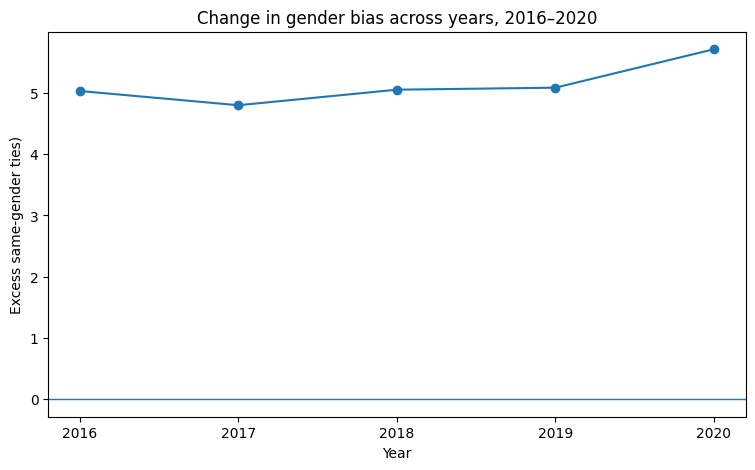

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(bias_by_year["year"],bias_by_year["same_gender_excess_pp"],marker="o")


plt.axhline(0, linewidth=1)

plt.xticks(bias_by_year["year"])
plt.xlabel("Year")
plt.ylabel("Excess same-gender ties)")
plt.title("Change in gender bias across years, 2016–2020")
plt.show()

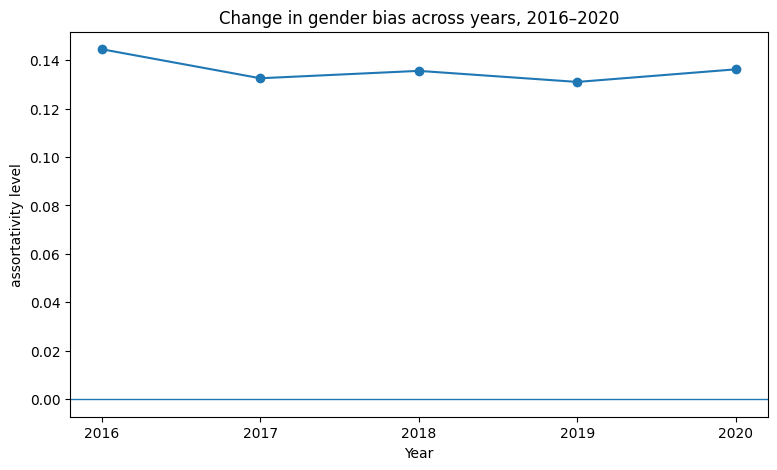

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(bias_by_year["year"],bias_by_year["assortativity"],marker="o")


plt.axhline(0, linewidth=1)

plt.xticks(bias_by_year["year"])
plt.xlabel("Year")
plt.ylabel("assortativity level")
plt.title("Change in gender bias across years, 2016–2020")
plt.show()